# Onderzoeksvragen


## data laden en preprocessen





In [2]:
import pandas as pd
import networkx as nx
import re
from collections import Counter
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [87]:
import pandas, numpy, networkx, igraph, leidenalg, powerlaw, scipy, matplotlib, seaborn
for m in [pandas,numpy,networkx,igraph,leidenalg,powerlaw,scipy,matplotlib,seaborn]:
    print(m.__name__, m.__version__)

pandas 2.3.3
numpy 2.3.5
networkx 3.5
igraph 1.0.0
leidenalg 0.11.0
powerlaw 2.0.0
scipy 1.16.3
matplotlib 3.10.6
seaborn 0.13.2


In [3]:
%%time
df= pd.read_csv('LidoLinks.csv.gz', header=None)
print(df.shape)
df.head()


(7355861, 2)
CPU times: total: 10.3 s
Wall time: 10.4 s


,0,1
0,jurisprudentie/id/ECLI:NL:RBAMS:2015:6776,bwb/id/BWBR0001854/2967974/1984-05-01/1984-05-01
1,jurisprudentie/id/ECLI:NL:RBOBR:2018:4470,bwb/id/BWBR0005290/2913524/2018-07-28/2018-07-28
2,jurisprudentie/id/ECLI:NL:RBAMS:2019:4496,bwb/id/BWBR0001854/2963144/1986-05-19/1986-05-19
3,jurisprudentie/id/ECLI:NL:RBOVE:2024:2366,bwb/id/BWBR0001827/3178144/2002-01-01/2002-01-01
4,jurisprudentie/id/ECLI:NL:RBUTR:2006:BA7009,bwb/id/BWBR0002375/2060994/2006-01-01/2006-01-01


In [4]:
%%time
# haal de datums van de id's af. Dit werkt alleen op de bwb/id knopen
df[1]=df[1].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 
df[0]=df[0].str.replace(r'(bwb.*?)(/[-0-9]+)?/[-0-9]+$',r'\1',regex=True) 

CPU times: total: 23.2 s
Wall time: 23.8 s


In [5]:
df['groep_s'] = df[0].str.replace(r'/id.*', r'', regex=True)
df['groep_t'] = df[1].str.replace(r'/id.*', r'', regex=True)

## 11. Onderzoeksvraag

**Hoofdvraag:** Welke structurele eigenschappen vertoont het Nederlandse jurisprudentie-citatienetwerk van Rechtspraak.nl, en hoe is juridische invloed binnen dit netwerk verdeeld over uitspraken, rechtsgebieden en rechterlijke instanties?

**DV1** Hoe valt de jurisprudentie-subgraaf uiteen in componenten, in hoeverre vertoont deze een bow-tie-structuur vergelijkbaar met die van het WWW (Broder et al., 2000), en welke dichte kernstructuren worden zichtbaar via k-core-analyse?

**DV2** Hoe is invloed verdeeld over uitspraken volgens in-degree, PageRank en HITS-authority, en in hoeverre vertonen deze verdelingen een power-law?

**DV3** In welke mate identificeren in-degree, PageRank en HITS-authority dezelfde uitspraken als invloedrijk, en zijn er systematische verschillen?

**DV4** Welke communities ontstaan via Leiden-detectie (Traag, Waltman & Van Eck, 2019) op de jurisprudentie-subgraaf, en in hoeverre vallen deze samen met de rechtsgebieden?

**DV5**  In welke mate komen citaties uit lagere instanties (rechtbank, kantongerecht) terecht bij hogere instanties (gerechtshof, Hoge Raad, Raad van State, CRvB, CBb), en wat zegt de assortativity over de hiërarchische structuur van het netwerk?

In [6]:
# G_jur: citatienetwerk (jurisprudentie -> jurisprudentie)
mask_jur = (df['groep_s'] == 'jurisprudentie') & (df['groep_t'] == 'jurisprudentie')
df_jur = df.loc[mask_jur, [0, 1]].copy()

# selfloops weghalen
self_loops = (df_jur[0] == df_jur[1]).sum()
df_jur = df_jur[df_jur[0] != df_jur[1]]

# dubbele edghes weghalen
n_before_dedup = len(df_jur)
df_jur = df_jur.drop_duplicates()
n_after_dedup = len(df_jur)

G_jur = nx.from_pandas_edgelist(df_jur, source=0, target=1, create_using=nx.DiGraph())

print('Citatienetwerk jur->jur:')
print(f'nodes:{G_jur.number_of_nodes():,}')
print(f'edges{G_jur.number_of_edges():,}')
print(f'zelfreferenties verwijderd:{self_loops:,}')
print(f'dubbele edges verwijderd:{n_before_dedup - n_after_dedup:,}')
print(f'dichtheid:{nx.density(G_jur):.2e}')


Citatienetwerk jur->jur:
nodes:674,589
edges1,353,664
zelfreferenties verwijderd:9
dubbele edges verwijderd:0
dichtheid:2.97e-06


## DV1  Macrostructuur van het netwerk


# motivatie
Voordat invloed binnen het netwerk kan worden gemeten, moet de globale structuur ervan in beeld worden gebracht. Broder et al. (2000) toonden aan dat het World Wide Web een bow-tie-structuur heeft met een centrale SCC van ongeveer 28% van de knopen. Voor citatienetwerken is het onduidelijk in hoeverre deze structuur toepasbaar is: citaties verwijzen in principe altijd naar eerdere uitspraken, waardoor de SCC klein zou moeten zijn. Tegelijk is bekend dat samenhangende verwijzingen, bijvoorbeeld tussen een conclusie van het Parket en de daaropvolgende uitspraak van de Hoge Raad, wel cyclische verbanden kunnen creëren. De k-core-analyse (Seidman, 1983; Carmi et al., 2007) bekijkt een andere vorm van structuur dan de bow-tie analyse. Waar de bow-tie rekening houdt met de richting van citaties, bekijkt k-core alleeen de onderlinge verbondenheid van uitspraken. Dit meet de ongerichte verbondenheid van het netwerk en kan dus een ander deel van het netwerk als "kern" identificeren dan een directionele maat.



1. Componenten (WCC en SCC)
2. ow-tie decompositie (Broder et al., 2000)
3. k-core decompositie (Seidman, 1983)

In [7]:
# zwakke componenten
wccs = list(nx.weakly_connected_components(G_jur))
wcc_sizes = sorted([len(c) for c in wccs], reverse=True)

print(f'aantal WCCs:       {len(wccs):,}')
print(f'grootste WCC:      {wcc_sizes[0]:,} knopen ({wcc_sizes[0]/G_jur.number_of_nodes()*100:.2f}%)')
print(f'2e grootste WCC:   {wcc_sizes[1] if len(wcc_sizes) > 1 else 0:,}')
print(f'aantal singletons: {sum(1 for s in wcc_sizes if s == 1):,}')

aantal WCCs:       67,837
grootste WCC:      526,576 knopen (78.06%)
2e grootste WCC:   33
aantal singletons: 0


In [8]:
# sterke componenten
sccs = list(nx.strongly_connected_components(G_jur))
scc_sizes = sorted([len(c) for c in sccs], reverse=True)

print(f'aantal SCCs:       {len(sccs):,}')
print(f'grootste SCC:      {scc_sizes[0]:,} knopen ({scc_sizes[0]/G_jur.number_of_nodes()*100:.4f}%)')
print(f'2e grootste SCC:   {scc_sizes[1] if len(scc_sizes) > 1 else 0:,}')
print(f'aantal singletons: {sum(1 for s in scc_sizes if s == 1):,}')

aantal SCCs:       553,067
grootste SCC:      103 knopen (0.0153%)
2e grootste SCC:   47
aantal singletons: 449,555


533k SCCs, waaronder 450k singletons. Dit is wat je verwacht van een citatienetwerk, nieuwe citaties verwijzen naar oudere citaties maar niet andersom. In een puur acyclisch en tijdsgeordent netwerk zou elke SCC een singeleton zijn. Toch is er een SCC van 103 knopen, dus dit betekent dat er cycles zijn. 

In [9]:
# in grootste SCC van G_jur
largest_scc = max(sccs, key=len)
print(f'grootste SCC: {len(largest_scc)} nodes')

# instantie verdeling
prefixes = Counter()
for ecli in largest_scc:
    m = re.search(r'ECLI:NL:([A-Z]+):', ecli)
    if m:
        prefixes[m.group(1)] += 1
print()
print('instanties in grootste SCC:')
for prefix, count in prefixes.most_common(10):
    print(f'  {prefix}: {count}')


grootste SCC: 103 nodes

instanties in grootste SCC:
  PHR: 40
  HR: 40
  GHARN: 5
  GHSHE: 5
  GHSGR: 3
  GHDHA: 3
  GHAMS: 2
  RBARN: 2
  RBZUT: 2
  RBAMS: 1


HR en PHR uitspraken vormen samen het grootste deel uit van het SCC. Dit zijn de instanties in de hoogste laag van het rechtssysteem en verwijzen vaak naar elkaar. Dit verklaart de gevonden cycles in het SCC.

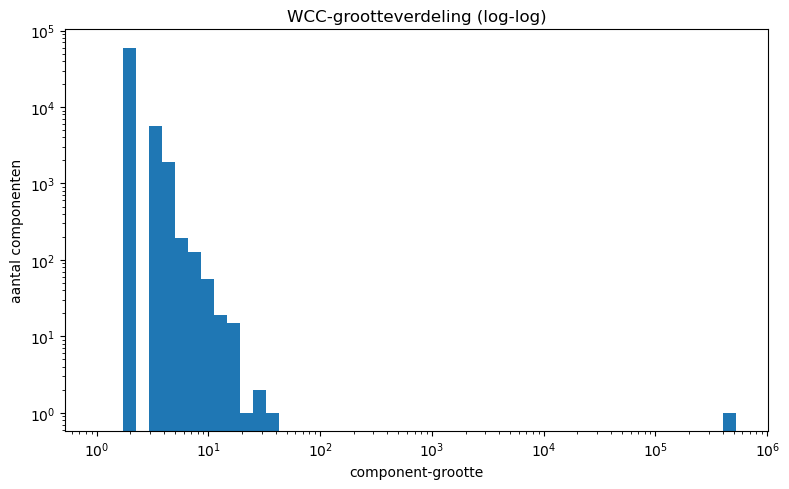

In [79]:
# WCC-grootteverdeling op loglog schaal
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(wcc_sizes, bins=np.logspace(0, np.log10(max(wcc_sizes)), 50))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('component-grootte')
ax.set_ylabel('aantal componenten')
ax.set_title('WCC-grootteverdeling (log-log)')
plt.tight_layout()
plt.show()


## bowtie

In [ ]:
def bowtie_decomposition(G):
    # grootste zwakke component
    largest_wcc = max(nx.weakly_connected_components(G), key=len)
    Gw = G.subgraph(largest_wcc)

    # grootste sterke component
    largest_scc = max(nx.strongly_connected_components(Gw), key=len)
    scc_node = next(iter(largest_scc))

    # IN: knopen die SCC kunnen bereiken
    G_rev = Gw.reverse(copy=False)
    can_reach_scc = nx.descendants(G_rev, scc_node) | {scc_node}

    # OUT: knopen bereikbaar vanuit SCC
    reachable_from_scc = nx.descendants(Gw, scc_node) | {scc_node}

    SCC = set(largest_scc)
    IN = can_reach_scc - SCC
    OUT = reachable_from_scc - SCC
    rest = set(Gw.nodes()) - SCC - IN - OUT

    # tendrils_in
    tendrils_in = set()
    frontier = {nbr for n in IN for nbr in Gw.successors(n)} & rest
    tendrils_in.update(frontier)
    while frontier:
        frontier = {nbr for n in frontier for nbr in Gw.successors(n)} & (rest - tendrils_in)
        tendrils_in.update(frontier)

    # tendrils_out
    rest2 = rest - tendrils_in
    tendrils_out = set()
    frontier = {nbr for n in OUT for nbr in Gw.predecessors(n)} & rest2
    tendrils_out.update(frontier)
    while frontier:
        frontier = {nbr for n in frontier for nbr in Gw.predecessors(n)} & (rest2 - tendrils_out)
        tendrils_out.update(frontier)

    # tubes: zitten in beide sets
    tubes = tendrils_in & tendrils_out
    tendrils_in -= tubes
    tendrils_out -= tubes

    other = rest - tendrils_in - tendrils_out - tubes

    return {
        'SCC': SCC,
        'IN': IN,
        'OUT': OUT,
        'TENDRILS_IN': tendrils_in,
        'TENDRILS_OUT': tendrils_out,
        'TUBES': tubes,
        'OTHER': other
    }

In [60]:
bowtie = bowtie_decomposition(G_jur)

total_wcc = sum(len(v) for v in bowtie.values())
total_net = G_jur.number_of_nodes()

df = pd.DataFrame([
    {
        'regio': region,
        'knopen': len(nodes),
        '% WCC': len(nodes) / total_wcc * 100,
        '% netwerk': len(nodes) / total_net * 100
    }
    for region, nodes in bowtie.items()
])

# totaalrijen
df.loc[len(df)] = ['totaal WCC', total_wcc, 100.0, total_wcc / total_net * 100]
df.loc[len(df)] = ['buiten WCC', total_net - total_wcc, None, (total_net - total_wcc) / total_net * 100]

df = df.set_index('regio')

display(df)

,knopen,% WCC,% netwerk
regio,,,
SCC,103,0.019560,0.015269
IN,23186,4.403163,3.437056
OUT,7726,1.467215,1.145290
TENDRILS_IN,101355,19.247934,15.024704
TENDRILS_OUT,110199,20.927463,16.335724
TUBES,0,0.000000,0.000000
OTHER,284007,53.934665,42.100746
totaal WCC,526576,100.000000,78.058788
buiten WCC,148013,NaN,21.941212


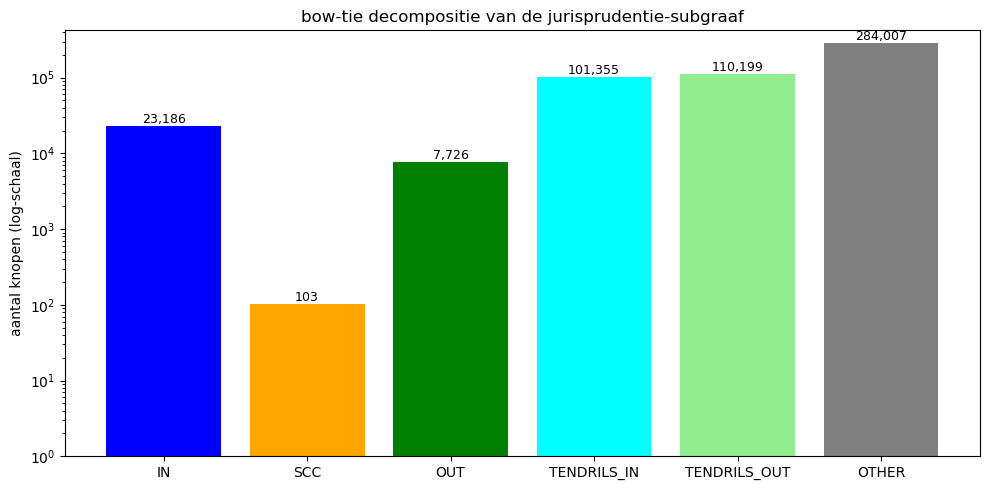

In [83]:
# bowtie visualiseren

fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    'IN': 'blue',
    'SCC': 'orange',
    'OUT': 'green',
    'TENDRILS_IN': 'cyan',
    'TENDRILS_OUT': 'lightgreen',
    'TUBES': 'yellow',
    'OTHER': 'gray'
}

plot_regions = [r for r in colors if len(bowtie[r]) > 0]
plot_sizes = [len(bowtie[r]) for r in plot_regions]
plot_colors = [colors[r] for r in plot_regions]

ax.bar(plot_regions, plot_sizes, color=plot_colors)
ax.set_yscale('log')
ax.set_ylim(bottom=1)
ax.set_ylabel('aantal knopen (log-schaal)')
ax.set_title('bow-tie decompositie van de jurisprudentie-subgraaf')

for i, s in enumerate(plot_sizes):
    ax.text(i, s, f'{s:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# k-core op ongerichte netwerk
G_jur_undirected = G_jur.to_undirected()

core_numbers = nx.core_number(G_jur_undirected)
print(f'maximale k-core: k = {max(core_numbers.values())}')

maximale k-core: k = 19


In [12]:
# distributie van core nr
core_dist = Counter(core_numbers.values())

print(f'{"k":>5}{"aantal knopen":>18}{"cumulatief":>15}')
cumulative = G_jur_undirected.number_of_nodes()
for k in sorted(core_dist.keys()):
    count = core_dist[k]
    print(f'{k:>5}{count:>18,}{cumulative:>15,}')
    cumulative -= count

    k     aantal knopen     cumulatief
    1           376,132        674,589
    2           128,019        298,457
    3            70,249        170,438
    4            40,290        100,189
    5            23,562         59,899
    6            15,798         36,337
    7            10,811         20,539
    8             5,345          9,728
    9             1,824          4,383
   10             1,091          2,559
   11               503          1,468
   12               418            965
   13               283            547
   14                67            264
   15                60            197
   16                25            137
   17                 2            112
   18                 1            110
   19               109            109


Op k=19 zitten 109 knopen, terweijl er in k=17 en k=18 maar 2 en 1 knopen zitten. Er is dus een dichte interne kern, 109 knopen die minstens 19 keer naar elkaar verwijzen. 

In [13]:
# binnenste core
max_k = max(core_numbers.values())
inner_core = [n for n, k in core_numbers.items() if k == max_k]

print(f'inner k-core (k={max_k}): {len(inner_core)}')

print('instanties in de binnenste k-core:')
prefixes = Counter()
for ecli in inner_core:
    m = re.search(r'ECLI:NL:([A-Z]+):', ecli)
    if m:
        prefixes[m.group(1)] += 1
for prefix, count in prefixes.most_common(15):
    print(f'  {prefix}: {count}')



inner k-core (k=19): 109
instanties in de binnenste k-core:
  RBOVE: 22
  RBGEL: 15
  RBOBR: 15
  HR: 10
  RBROT: 8
  RBDHA: 8
  RBZWB: 7
  RBMNE: 6
  RBNHO: 5
  RBLIM: 4
  GHARL: 3
  GHAMS: 3
  RBAMS: 2
  GHSHE: 1


Groot contrast met SCC resultaten. Hier is de top juist gedomineerd door rechtbanken, slechts 10 van de 109 zijn HR en heleemaal geen PHR.

Verklaring: Ongericht vs gericht. K-core meet lokale dichtheid in een ongericht netwerk, dus d de richting van citaties speelt geen rol. Rechtbanken citeren in absolute aantallen veel andere rechtbanken, vooral binnen hetzelfde rechtsgebied, en deze 

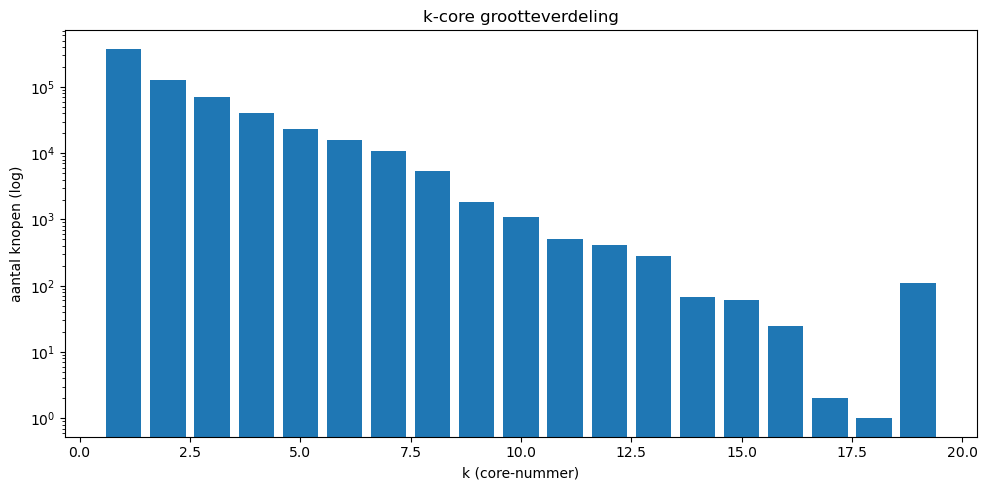

In [14]:
# verdeling plotten
ks = sorted(core_dist.keys())
counts = [core_dist[k] for k in ks]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ks, counts)
ax.set_yscale('log')
ax.set_xlabel('k (core-nummer)')
ax.set_ylabel('aantal knopen (log)')
ax.set_title('k-core grootteverdeling')
plt.tight_layout()
plt.show()


### Resultaten
**componenten** De jurisprudentie-subgraaf telt 67.837 zwakke componenten (WCC's). De grootste WCC omvat 526.576 knopen (78,06% van het netwerk). De tweede WCC bevat slechts 33 knopen en de rest van de zwakke componenten zijn nog kleiner. De decompositie in sterke componenten (SCC's) geeft een heel ander beeld: 553.067 SCC's waarvan er 449.555 uit één knoop bestaan. De grootste SCC bevat slechts 103 knopen (0,0153% van het netwerk) en de tweede grootste 47 knopen. De grootste SCC bestaat vrijwel volledig uit Hoge Raad-uitspraken (HR: 40) en bijbehorende conclusies van het Parket bij de Hoge Raad (PHR: 40), en enkele uitspraken van gerechtshoven (GHARN, GHSHE, GHSGR, GHDHA, GHAMS) en rechtbanken.


**bow-tie-decompositie** De SCC vormt 0,02% van het netwerk, IN (knopen die de SCC kunnen bereiken) 3,44% en OUT (knopen bereikbaar vanuit de SCC) 1,15%. De tendrils zijn aanzienlijk groter dan de centrale onderdelen: TENDRILS_IN bevat 101.355 knopen (15,02%) en TENDRILS_OUT 110.199 knopen (16,34%). Daarnaast zijn er geen tubes gevonden. De grootste categorie is OTHERS met 284.007 knopen (42,10%): knopen die binnen de grootste WCC liggen maar geen pad van of naar de SCC hebben. Daarnaast staan 148.013 knopen (21,9%) volledig buiten de grootste WCC.


**k-core-decompositie.** Op de ongerichte projectie van de subgraaf is de maximale k-core k=19. De distributie loopt sterk af: 376.132 knopen hebben core-nummer 1 en bijna 56% van het netwerk valt weg na het verwijderen van knopen met core-nummer 2 of lager. De binnenste k-core bevat 109 knopen en heeft een opvallende instantieverdeling: de kern wordt gedomineerd door rechtbanken (RBOVE: 22, RBGEL: 15, RBOBR: 15, RBROT: 8, RBDHA: 8, RBZWB: 7), met daarnaast 10 Hoge Raad-uitspraken en enkele gerechtshoven (GHARL, GHAMS, GHSHE). Hogere bestuursrechters (RvS, CRvB, CBb) ontbreken in deze kern. 

### Interpretatie
De macrostructuur van het Nederlandse jurisprudentienetwerk verschilt sterk met die van het World Wide Web. Waar de SCC in het WWW ongeveer 28% van het netwerk omvat (Broder et al., 2000), bevat de SCC in deze subgraaf slechts 0,02%. Dit komt overeen met de vewachting: juridische citaties wijzen in principe altijd naar het verleden, waardoor wederzijdse verwijzingen tussen uitspraken zeldzaam zijn. De 103  cyclisch verbonden uitspraken bestaan bijna alleen uit HR-uitspraken en hun bijbehorende PHR-conclusies. Dit is te verklaren doordat een conclusie en de daaropvolgende uitspraak naar elkaar verwijzen, en die paren via gedeelde citaties binnen de HR jurisprudentie onderling verbonden zijn.

De afwezigheid van een grote SCC betekent niet dat het netwerk fragmentarisch is: 78% van de knopen ligt in één grote zwakke component. De ...

de meeste uitspraken citeren wel, maar maken geen deel uit van wederkerige

## DV2 Verdeling van invloed

# motivatie
Eerdere studies naar juridische citatienetwerken concentreren zich op het identificeren van invloedrijke uitspraken met behulp van centraliteitsmaten zoals in-degree, PageRank (Brin en Page, 1998; Winkels en De Ruyter, 2012) en de importance scores van Fowler et al. (2007). Wat in de literatuur opvalt is dat de keuze van maat de uitkomst sterk beïnvloedt (Fowler en Jeon, 2008; Van Opijnen, 2012). Deze deelvraag richt zich daarom niet op het kiezen van de "beste" maat, maar op de verdeling die elke maat oplevert: hoe sterk is invloed geconcentreerd, en heeft de staart van de verdeling de power-law-vorm die in veel netwerkliteratuur wordt verwacht? Broido en Clauset (2019) lieten zien dat strikte schaalvrije netwerken zeldzamer zijn dan vaak wordt aangenomen en dat log-normale verdelingen vaak even goed of zelfs beter bij de data passen. 


Drie maten naast elkaar: in-degree, PageRank, HITS-authority. Voor elke maat: verdeling, ongelijkheid (Gini), concentratie aan de top, en power-law-fit volgens Clauset, Shalizi en Newman (2009).

In [15]:
# in-degree
in_degree = dict(G_jur.in_degree())

# PageRank
pagerank = nx.pagerank(G_jur, alpha=0.85)

# HITS
hubs, authorities = nx.hits(G_jur, max_iter=200, tol=1e-6)

In [16]:
df_scores = pd.DataFrame({
    'ecli': list(G_jur.nodes()),
})
df_scores['in_degree'] = df_scores['ecli'].map(in_degree)
df_scores['pagerank'] = df_scores['ecli'].map(pagerank)
df_scores['authority'] = df_scores['ecli'].map(authorities)
print(df_scores.shape)
df_scores.describe()

(674589, 4)


,in_degree,pagerank,authority
count,674589.000000,6.745890e+05,6.745890e+05
mean,2.006650,1.482384e-06,1.482384e-06
std,33.048509,1.260278e-05,2.733803e-04
min,0.000000,5.987837e-07,-5.394770e-17
25%,0.000000,5.987837e-07,0.000000e+00
50%,1.000000,8.106188e-07,1.919041e-19
75%,1.000000,1.559940e-06,1.510269e-09
max,21160.000000,7.226992e-03,2.235883e-01


## ongelijkheid en concentratie

In [17]:
# Gini-coef (0 = volledig gelijk, 1 = volledig ongelijk)
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    if x.sum() == 0:
        return 0
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x)) / (n * x.sum()) - (n + 1) / n

def top_k_share(x, k_frac):
    x = np.sort(np.asarray(x, dtype=float))[::-1]
    k = max(1, int(np.ceil(len(x) * k_frac)))
    return x[:k].sum() / x.sum() if x.sum() > 0 else 0.0


rows = []

for col in ['in_degree', 'pagerank', 'authority']:
    x = df_scores[col].values
    rows.append({
        'maat': col,
        'Gini': gini(x),
        'top-1%': top_k_share(x, 0.01),
        'top-5%': top_k_share(x, 0.05),
        'top-10%': top_k_share(x, 0.10)
    })

summary = pd.DataFrame(rows)

summary[['Gini', 'top-1%', 'top-5%', 'top-10%']] = summary[
    ['Gini', 'top-1%', 'top-5%', 'top-10%']
].round(3)

summary



,maat,Gini,top-1%,top-5%,top-10%
0,in_degree,0.759,0.371,0.573,0.670
1,pagerank,0.457,0.195,0.314,0.394
2,authority,0.977,0.661,0.984,0.997


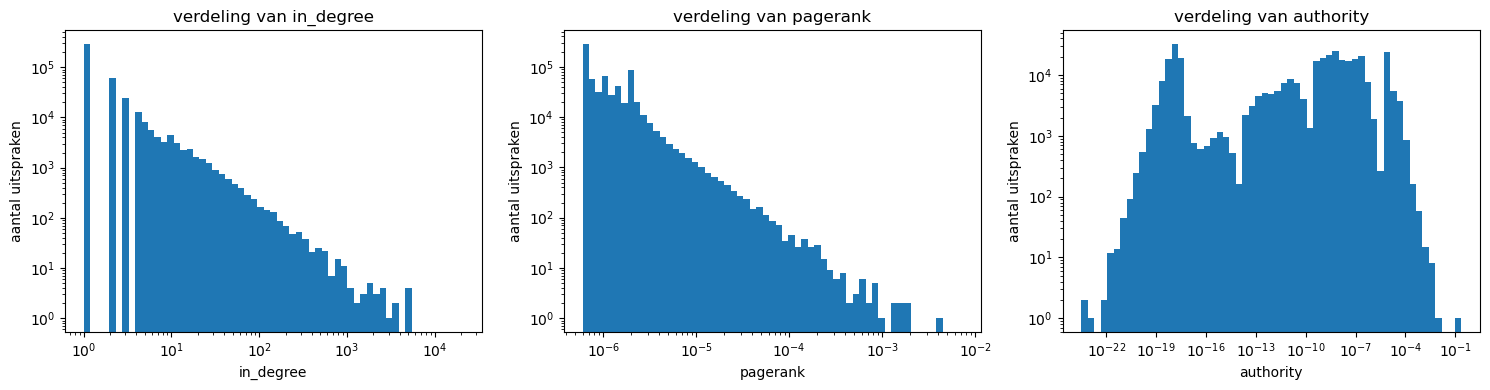

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols = ['in_degree', 'pagerank', 'authority']

for ax, col in zip(axes, cols):
    vals = df_scores[col].values
    vals = vals[vals > 0]

    ax.hist(vals, bins=np.logspace(np.log10(vals.min()),
                                   np.log10(vals.max()), 60))

    ax.set(xscale='log',
           yscale='log',
           xlabel=col,
           ylabel='aantal uitspraken',
           title=f'verdeling van {col}')

plt.tight_layout()
plt.show()

Verdeling in-degree:
De verdeling van het in-degree heeft een gelijke afname, dus een kandidaat voor power-law .  ''survival of the fittest'', een klein aantal uitspraken wordt heel vaak geciteerd

Verdeling pagerank: Deze neemt nog gelijker af en laat ook een power-law patroon zien

Verdeling van authority: Deze wijkt heel erg af van de andere twee en heeft meerdere pieken. 

## powerlaw fits

In [19]:
import powerlaw
import warnings
warnings.filterwarnings('ignore')


In [20]:
fits = {}

for col in ['in_degree', 'pagerank', 'authority']:
    vals = df_scores[col].values
    vals = vals[vals > 0]

    fits[col] = powerlaw.Fit(vals, discrete=False, verbose=False)

In [29]:
import pickle
with open('fits.pkl', 'wb') as f:
    pickle.dump(fits, f)

In [21]:
rows = []

names = {
    'in_degree': 'In-degree',
    'pagerank': 'PageRank',
    'authority': 'HITS-authority'
}

for col, fit in fits.items():
    vals = df_scores[col].values
    vals = vals[vals > 0]

    for alt in ['lognormal', 'exponential', 'stretched_exponential']:
        R, p = fit.distribution_compare(
            'power_law',
            alt,
            normalized_ratio=True
        )

        rows.append({
            'maat': names[col],
            'alpha': fit.alpha,
            'xmin': fit.xmin,
            'KS': fit.D,
            'obs_tail': (vals >= fit.xmin).sum(),
            'vergelijking': f'power_law vs {alt}',
            'R': R,
            'p': p,
            'beste_model': 'power_law' if R > 0 else alt
        })

df_powerlaw = pd.DataFrame(rows)
df_powerlaw.round(4)

,maat,alpha,xmin,KS,obs_tail,vergelijking,R,p,beste_model
0,In-degree,2.4278,39.0000,0.0099,3136,power_law vs lognormal,-0.7030,0.4820,lognormal
1,In-degree,2.4278,39.0000,0.0099,3136,power_law vs exponential,5.8406,0.0000,power_law
2,In-degree,2.4278,39.0000,0.0099,3136,power_law vs stretched_exponential,3.2011,0.0014,power_law
3,PageRank,2.3780,0.0000,0.0048,16334,power_law vs lognormal,-0.5858,0.5580,lognormal
4,PageRank,2.3780,0.0000,0.0048,16334,power_law vs exponential,9.1380,0.0000,power_law
5,PageRank,2.3780,0.0000,0.0048,16334,power_law vs stretched_exponential,4.0513,0.0001,power_law
6,HITS-authority,2.1858,0.0002,0.0343,219,power_law vs lognormal,-1.0162,0.3096,lognormal
7,HITS-authority,2.1858,0.0002,0.0343,219,power_law vs exponential,2.2358,0.0254,power_law
8,HITS-authority,2.1858,0.0002,0.0343,219,power_law vs stretched_exponential,0.7777,0.4368,power_law


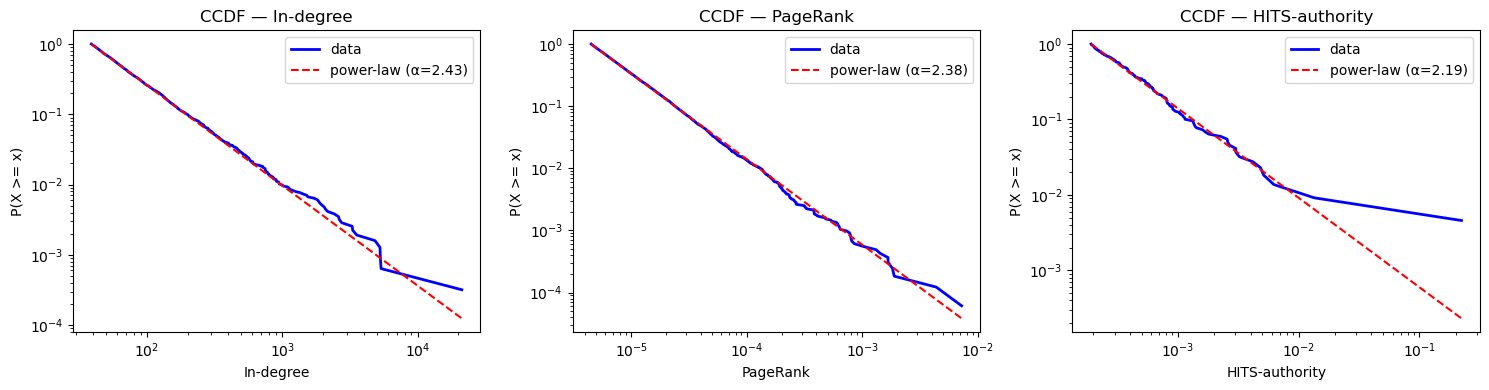

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, name) in zip(axes, [('in_degree', 'In-degree'),
                                   ('pagerank', 'PageRank'),
                                   ('authority', 'HITS-authority')]):
    fit = fits[col]
    fit.plot_ccdf(ax=ax, color='blue', linewidth=2, label='data')
    fit.power_law.plot_ccdf(ax=ax, color='red', linestyle='--', label=f'power-law (α={fit.alpha:.2f})')
    ax.set_xlabel(name)
    ax.set_ylabel('P(X >= x)')
    ax.set_title(f'CCDF — {name}')
    ax.legend()
plt.tight_layout()
plt.show()

- In-degree: de curve van de indegree volgt de fit redelijk goed, maar buigt op het einde rechts ietst boven de fit uit. Er is een extremere tail dan een zuivere powerlaw voorspeelt.

- Pagerank: volgt de lijn het beste van de drie, met een kleine afwijking helemaal rechts.

- HITS: rechts buigt de curve sterk boven de fit uit. Er is een groep met heel hoge authority die niet bij de powerlaw fit past, waarschijnmlijk hetzelfde HR/PHR cluster die in de SCC zit. 

### Resultaten
**Concentratie en ongelijkheid.** De drie invloedmaten vertonen sterk scheve verdelingen, maar in verschillende maten. Voor in-degree geldt een Gini-coëfficiënt van 0,759, met de top-1% van uitspraken die 37,1% van alle citaties ontvangt en de top-10% 67,0%. PageRank is duidelijk minder ongelijk verdeeld (Gini 0,457; top-1% 19,5%; top-10% 39,4%), ..... HITS-authority laat een veel extremere concentratie zien (Gini 0,974): de top-1% van uitspraken bevat 66,1% van alle authority en de top 10% 99,7%. De rest van het netwerk heeft praktisch geen authority.

**Power-law-fits.** Volgens de procedure van Clauset, Shalizi en Newman (2009) zijn voor alle drie de maten power-law-fits berekend. 


De likelihood ratio tests laten echter zien dat het power-law-model niet beter past dan alle alternatieven modellen. Tegen het exponentiële model wint power-law steeds duidelijk (R = +5,84 voor in-degree; R = +9,14 voor PageRank; R = +2,24 voor authority; alle p < 0,05). 

### Interpretatie
De drie invloedmaten geven een consistent beeld: invloed in het Nederlandse jurisprudentienetwerk is zwaar geconcentreerd, maar wat als invloed naar voren komt verschilt per maat. PageRank produceert een minder geconcentreerde verdeling (Gini 0,457), doordat de teleportatieterm elke knoop een minimumkans op aandacht garandeert en zo de staart afvlakt. In-degree zit daarboven (Gini 0,759). HITS-authority is met een Gini van 0,974 verreweg het scheefst verdeeld: de top-1% bevat tweederde van alle authority-massa en de rest van het netwerk heeft vrijwel geen authority.

Dat de power-law-staart voor alle drie de maten een exponent rond 2 geeft valt in lijn met eerder gerapporteerde bevindingen voor citatienetwerken. De likelihood ratio tests ondersteunen echter de waarschuwing van Broido en Clauset (2019): een rechte lijn in een log-log-plot is geen direct bewijs voor een power-law. Voor alle drie de maten past de log-normale verdeling minstens even goed bij de data als een power law. Voor HITS-authority past ook een stretched exponential even goed. De resultaten geven daardoor geen duidelijke voorkeur voor een power law boven deze alternatieve verdelingen.

Inhoudelijk heeft het Nederlandse jurisprudentienetwerk dus een zwaar-scheve verdeling van invloed die qua vorm lijkt op klassieke power-law-netwerken,


## DV3 Overeenstemming tussen invloedmaten


## motivatie
DV2 beschrijft de drie invloedmaten afzonderlijk. De vervolgvraag is in hoeverre deze maten dezelfde uitspraken als invloedrijk aanwijzen. Fowler en Jeon (2008) vonden voor het Amerikaanse Supreme Court dat hun importance score (een PageRank-variant) en in-degree slechts gedeeltelijk dezelfde invloedrijke uitspraken identificeren. Winkels, De Ruyter en Kroese (2011) vergeleken voor Nederlandse rechtspraak in-degree en PageRank en vonden juist weinig verschil tussen beide maten. Van Opijnen (2012) liet vervolgens zien dat verschillende netwerkmaten tot verschillende rangschikkingen van uitspraken kunnen leiden. In deze deelvraag wordt dit systematisch onderzocht op het volledige jurisprudentienetwerk via rangcorrelatie over alle uitspraken (Spearman, Kendall) en via Jaccard-overlap aan de top. Dit onderscheid is inhoudelijk relevant: een hoge rangcorrelatie over alle 674k knopen sluit niet uit dat de top-10 verschilt, terwijl juist de top in juridisch onderzoek vaak centraal staat. Daarnaast onderzoekt deze deelvraag of de gevonden afwijkingen tussen de maten systematisch samenhangen met het jaar van de uitspraak, omdat oudere uitspraken in PageRank anders worden gewogen dan bij in-degree.


rangcorrelatie over de volledige ranking en Jaccard-overlap aan de top

In [23]:
from scipy.stats import spearmanr, kendalltau
rows = []

pairs = [
    ('in_degree', 'pagerank'),
    ('in_degree', 'authority'),
    ('pagerank', 'authority')
]

for a, b in pairs:
    rho, _ = spearmanr(df_scores[a], df_scores[b])
    tau, _ = kendalltau(df_scores[a], df_scores[b])

    print(f'{a} vs {b:<20}  Spearman={rho:.4f}  Kendall={tau:.4f}')

in_degree vs pagerank              Spearman=0.8433  Kendall=0.7157
in_degree vs authority             Spearman=0.6459  Kendall=0.5369
pagerank vs authority             Spearman=0.3527  Kendall=0.2627


In-degree en pagerank komen best wel sterk overeen (ρ=0,84, τ=0,72), deze identificeren grotendeels dezelfde uitspraken als invloedrijk. Tussen in-degree en HITS-authority is een matige correlatie (ρ=0,65, τ=0,54). PageRank en HITS-authority hebben de allerlaagste correlatie (ρ=0,35, τ=0,26). DIt wijst erop dat HITS-authority een andere groep invloedrijke uitspraken identificeert.

## top -k Jaccard overlap

In [42]:
def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / len(a | b) if a | b else 0.0

rows = []

for k in [10, 100, 1000, 10_000]:
    top_id = df_scores.nlargest(k, 'in_degree')['ecli']
    top_pr = df_scores.nlargest(k, 'pagerank')['ecli']
    top_auth = df_scores.nlargest(k, 'authority')['ecli']

    rows.append({
        'k': k,
        'id ∩ pr': jaccard(top_id, top_pr),
        'id ∩ auth': jaccard(top_id, top_auth),
        'pr ∩ auth': jaccard(top_pr, top_auth)
    })
    
df_overlap = pd.DataFrame(rows)
df_overlap.round(4)



,k,id ∩ pr,id ∩ auth,pr ∩ auth
0,10,0.5385,0.4286,0.4286
1,100,0.4706,0.3333,0.2195
2,1000,0.4255,0.2796,0.1514
3,10000,0.4132,0.2822,0.1634


## hoe wijken de maten af

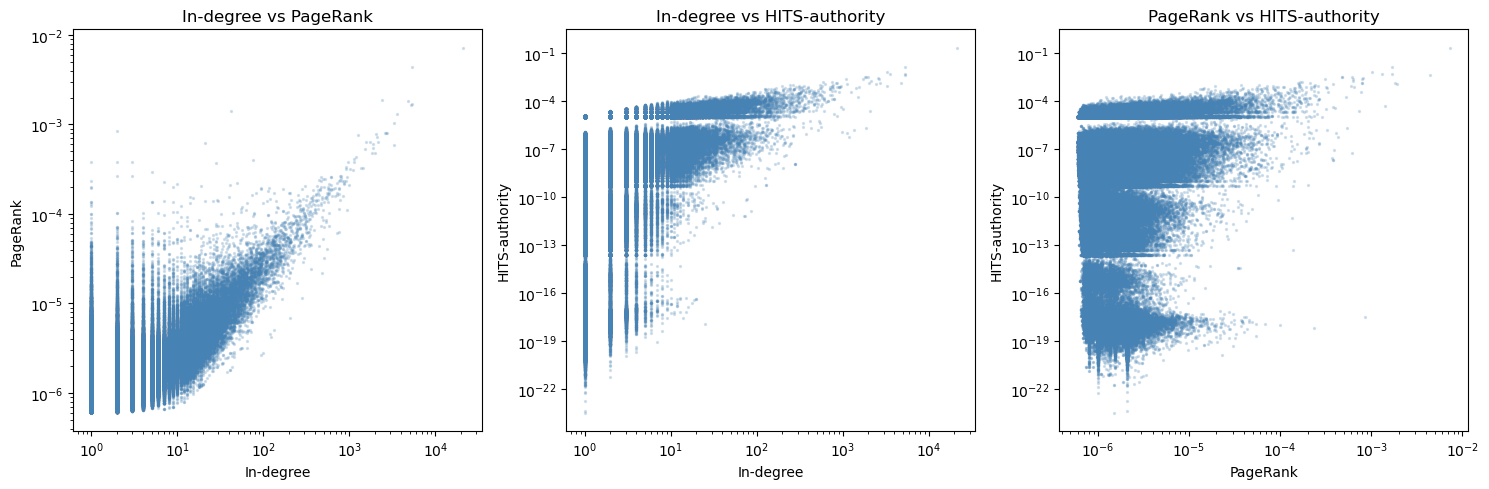

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [('in_degree', 'pagerank', 'In-degree', 'PageRank'),
         ('in_degree', 'authority', 'In-degree', 'HITS-authority'),
         ('pagerank', 'authority', 'PageRank', 'HITS-authority')]

for ax, (a, b, la, lb) in zip(axes, pairs):
    ax.scatter(
        df_scores[a],
        df_scores[b],
        s=2,
        alpha=0.2,
        color='steelblue'
    )

    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xlabel(la)
    ax.set_ylabel(lb)
    ax.set_title(f'{la} vs {lb}')

plt.tight_layout()
plt.show()

# systematische verschillen

In [ ]:
df_scores['rank_in_degree'] = df_scores['in_degree'].rank(ascending=False, method='min')
df_scores['rank_pagerank']  = df_scores['pagerank'].rank(ascending=False, method='min')
df_scores['rank_authority'] = df_scores['authority'].rank(ascending=False, method='min')

# jaar extractem uit ecli
def extract_year(ecli):
    m = re.search(r'ECLI:NL:[A-Z]+:(\d{4}):', ecli)
    return int(m.group(1)) if m else None

df_scores['jaar'] = df_scores['ecli'].apply(extract_year)
print(df_scores[['jaar']].describe())


                jaar
count  662777.000000
mean     2012.856285
std        10.446542
min      1862.000000
25%      2009.000000
50%      2015.000000
75%      2020.000000
max      2024.000000


verdeling is rechtsscheef, gemiddelde is 2013 en is lager dan mediaan (2015). Er is een lange staart van oude uitspraken die het gemiddelde naar beneden haalt.

bulk zit tussen 2009 en 2020


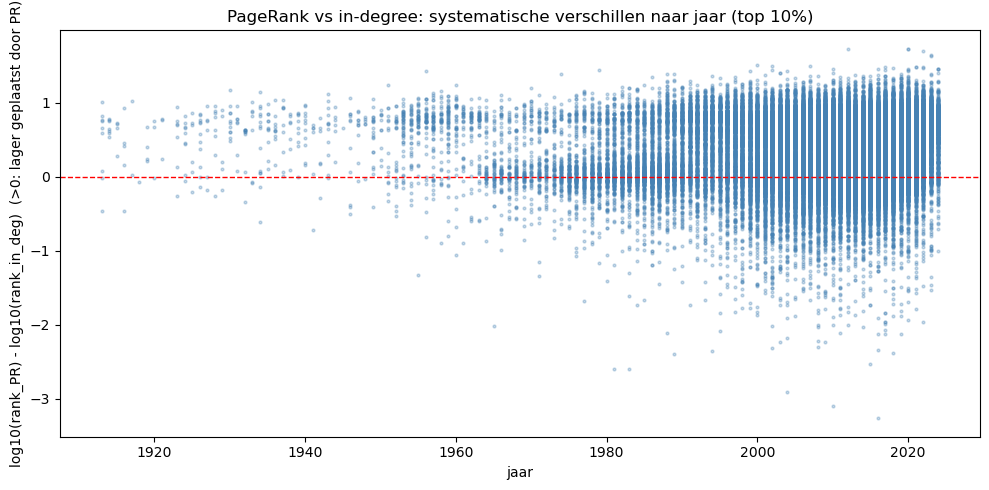

In [93]:
# krijgen oudere uitspraken een hogere of lagere PageRank dan in-degree

df_scores['rank_diff_pr_id'] = np.log10(df_scores['rank_pagerank']) - np.log10(df_scores['rank_in_degree'])

threshold = df_scores['in_degree'].quantile(0.9)
focus = df_scores[(df_scores['in_degree'] >= threshold) & df_scores['jaar'].notna()]


threshold = df_scores['in_degree'].quantile(0.9)
focus = df_scores[(df_scores['in_degree'] >= threshold) & df_scores['jaar'].notna()]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(focus['jaar'], focus['rank_diff_pr_id'], s=4, alpha=0.3, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('jaar')
ax.set_ylabel('log10(rank_PR) - log10(rank_in_deg)  (>0: lager geplaatst door PR)')
ax.set_title('PageRank vs in-degree: systematische verschillen naar jaar (top 10%)')
plt.tight_layout()
plt.show()



## resultaten
**Rangcorrelaties.** Over alle 674.589 knopen vertonen de drie invloedmaten verschillende mate van rangcorrelatie. In-degree en PageRank zijn sterk met elkaar gecorreleerd (Spearman ρ = 0,843; Kendall τ = 0,716). De overeenstemming tussen in-degree en HITS-authority is matig (ρ = 0,647; τ = 0,538), terwijl de correlatie tussen PageRank en HITS-authority laag is (ρ = 0,353; τ = 0,263).

**Top-k Jaccard-overlap.** De rangcorrelaties zeggen iets over het netwerk als geheel, maar voor inhoudelijke interpretatie is vooral relevant of de maten dezelfde uitspraken aan de top plaatsen. In-degree en PageRank delen 0,54 van hun top-10 (4 van de 10 uitspraken) en 0,41 van hun top-10.000. De overlap tussen in-degree en HITS-authority schommelt rond 0,28–0,43, en die tussen PageRank en HITS-authority is consistent het laagst (0,15–0,43). Opvallend is dat de overlap voor in-degree vs. PageRank relatief stabiel blijft over verschillende k-waarden, terwijl de overlap met HITS-authority sterker daalt naarmate k toeneemt.

**leeftijd effect**

## Interpretatie


Het algoritme van Kleinberg (1999) gaat ervan uit dat goede authorities herkenbaar zijn doordat zij worden geciteerd door goede hubs, en omgekeerd. Op het Nederlandse jurisprudentienetwerk werkt deze wederzijdse versterking heel sterk in het voordeel van de Hoge Raad-cluster: conclusies van het Parket bij de Hoge Raad zijn extreme hubs, omdat een PHR-conclusie standaard tientallen tot honderden HR-uitspraken citeert. De citatieflow uit DV5 maakt dit zichtbaar: 84% van alle uitgaande PHR-citaties verwijst naar HR-uitspraken, en de stroom PHR → HR (202.605 citaties) is de grootste enkele stroom in het hele netwerk. Hierdoor krijgen PHR-knopen een hele hoge hub-score. HR-uitspraken waarnaar veel van deze PHR-conclusies verwijzen krijgen daardoor weer extreem hoge authority. 

Dit is hetzelfde mechanisme dat in de HITS-literatuur bekendstaat als het tightly-knit community-effect(Lempel en Moran, 2001): een kleine groep wederzijds dicht verbonden knopen kan de authority-scores van de rest van het netwerk wegdrukken, ookal heeft die rest een aanzienlijk hoog in-degree. De observatie uit DV1 dat de grootste SCC (103 knopen) vrijwel volledig uit PHR- en HR-knopen bestaat, levert het structurele bewijs voor deze interpretatie: precies deze knopen vormen de cyclische kern die tijdens de HITS-iteratie steeds meer gewicht krijgt.

De resultaten laten zien dat HITS-authority in dit netwerk iets anders meet dan algemene juridische invloed. Uitspraken van de Hoge Raad en conclusies van het Parket bij de Hoge Raad vormen samen een kleine, sterk verbonden groep waarin authority-scores zich concentreren . Daardoor kunnen uitspraken met veel ontvangen citaties toch een relatief lage authority-score hebben wanneer zij weinig worden geciteerd vanuit deze HR-PHR-structuur. HITS-authority lijkt daarmee vooral gevoelig voor de positie van een uitspraak binnen dit onderdeel van het netwerk. Of dit een gebrek of een functie van HITS is, hangt af van het onderzoeksdoel. Voor onderzoek naar invloed binnen de Hoge Raad-jurisprudentie kan dit juist waardevolle informatie opleveren. Voor een bredere interpretatie van juridische invloed is het echter belangrijk authority naast andere maten te gebruiken. Dit sluit aan bij Fowler en Jeon (2008), die benadrukken dat invloed in juridische citatienetwerken niet door één enkele maat kan worden gevangen

## DV4  Communities en rechtsgebieden

## motivatie


Leiden community detection (Traag, Waltman & Van Eck, 2019) op de ongerichte projectie. Resultaten vergelijken met rechtsgebied-labels via modulariteit, ARI en NMI.

In [45]:
import igraph as ig
import leidenalg as la

G_ig = ig.Graph.from_networkx(G_jur_undirected)
print(f'igraph: {G_ig.vcount():,} nodes, {G_ig.ecount():,} edges')

igraph: 674,589 nodes, 1,228,540 edges


In [61]:
leiden_results = []
for seed in [0, 1, 2, 3, 4]:
    partition = la.find_partition(G_ig, la.ModularityVertexPartition, seed=seed)
    leiden_results.append({
        'seed': seed,
        'n_communities': len(partition),
        'modularity': partition.modularity,
        'partition': partition,
    })
    print(f'seed {seed}: {len(partition):,} communities, Q = {partition.modularity:.4f}')


seed 0: 68,091 communities, Q = 0.8569
seed 1: 68,067 communities, Q = 0.8566
seed 2: 68,076 communities, Q = 0.8569
seed 3: 68,091 communities, Q = 0.8573
seed 4: 68,129 communities, Q = 0.8566


In [94]:
# beste Leiden kiezen (hoogste modulariteit)
best = max(leiden_results, key=lambda r: r['modularity'])
partition_best = best['partition']
node_comm = {G_ig.vs[i]['_nx_name']: c for i, c in enumerate(partition_best.membership)}
comm_sizes = Counter(node_comm.values())

print(f"best: seed {best['seed']}, {best['n_communities']:,} communities, Q={best['modularity']:.4f}")
print(f"grootste 5 communities (id, grootte): {comm_sizes.most_common(5)}")


best: seed 3, 68,091 communities, Q=0.8573
grootste 5 communities (id, grootte): [(0, 46500), (1, 42102), (2, 37097), (3, 31339), (4, 30858)]


In [ ]:
import time, re, json, os, requests
import xml.etree.ElementTree as ET

CONTENT_URL = 'https://data.rechtspraak.nl/uitspraken/content'
NS_DC = '{http://purl.org/dc/terms/}'
CACHE_PATH = 'dv4_rechtsgebied_cache.json'

rg_cache = json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}

def _ecli_to_api_id(node):
    m = re.search(r'ECLI[.:]NL[.:]([A-Z]+)[.:]([0-9]{4})[.:]([A-Z0-9.]+)', node, re.I)
    if not m:
        return None
    nr = m.group(3).replace('.', ':').upper()
    return f'ECLI:NL:{m.group(1).upper()}:{m.group(2)}:{nr}'

def fetch_rechtsgebied(node, sleep=1.1):
    # hoofd = hoofdrechtsgebied (1e niveau), full = volledige subject teksten
    # cache gebruiken om dubbele API calls te voorkomen
    if node in rg_cache:
        return rg_cache[node]
    res = {'ecli': None, 'hoofd': [], 'full': [], 'status': 0}
    ecli = _ecli_to_api_id(node)
    res['ecli'] = ecli

    # als er geen ecli uit node te extraheren is, cache resultaat
    if ecli is None:
        rg_cache[node] = res
        return res
    
    # wachttijd om API niet te overbelasten
    time.sleep(sleep)
    try:
        r = requests.get(CONTENT_URL, params={'id': ecli, 'return': 'META'}, timeout=20)
        res['status'] = r.status_code
        if r.status_code == 200:
            root = ET.fromstring(r.content)
            for s in root.iter(NS_DC + 'subject'):
                t = (s.text or '').strip()
                if t:
                    res['full'].append(t)
                    res['hoofd'].append(t.split(';')[0].strip())
    except Exception as e:
        res['fout'] = str(e)
    rg_cache[node] = res
    return res

In [ ]:
import random
SAMPLE_SIZE = 1500
random.seed(42)

# random sample uit Leiden knopen
sample_nodes = random.sample(list(node_comm), min(SAMPLE_SIZE, len(node_comm)))

for k, node in enumerate(sample_nodes, 1):
    # rechtsgebied ophalen
    fetch_rechtsgebied(node)
    if k % 100 == 0:
        json.dump(rg_cache, open(CACHE_PATH, 'w'))
        print(f"  {k}/{len(sample_nodes)} opgehaald")
json.dump(rg_cache, open(CACHE_PATH, 'w'))

# primaire labels = hoofdrechtsgebied
rg_primary = {n: rg_cache[n]['hoofd'][0] for n in sample_nodes if rg_cache[n]['hoofd']}
print(f"\n{len(rg_primary)}/{len(sample_nodes)} knopen met rechtsgebied "
      f"({len(rg_primary)/len(sample_nodes):.0%} dekking)")
print("rechtsgebied-verdeling in sample:")
for rg, c in Counter(rg_primary.values()).most_common():
    print(f"  {rg:<32}{c}")

  100/1500 opgehaald
  200/1500 opgehaald
  300/1500 opgehaald
  400/1500 opgehaald
  500/1500 opgehaald
  600/1500 opgehaald
  700/1500 opgehaald
  800/1500 opgehaald
  900/1500 opgehaald
  1000/1500 opgehaald
  1100/1500 opgehaald
  1200/1500 opgehaald
  1300/1500 opgehaald
  1400/1500 opgehaald
  1500/1500 opgehaald

1366/1500 knopen met rechtsgebied (91% dekking)
rechtsgebied-verdeling in sample:
  Bestuursrecht                   732
  Civiel recht                    324
  Strafrecht                      310


[hoofdrechtsgebied] n=1366, klassen=  3, ARI=0.0538, NMI=0.2876, AMI=0.2084, homogeniteit=0.7996
[specifiek] n=1366, klassen= 24, ARI=0.1331, NMI=0.4543, AMI=0.3010, homogeniteit=0.7169


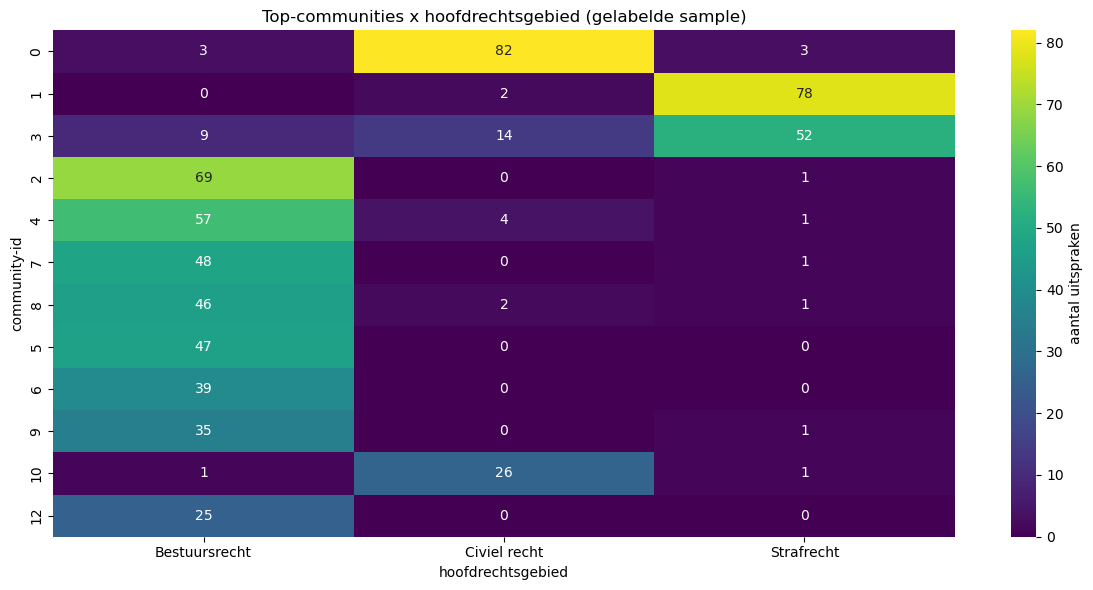

zuiverheid per top-community (aandeel dominant rechtsgebied):
community
0     0.93
1     0.98
3     0.69
2     0.99
4     0.92
7     0.98
8     0.94
5     1.00
6     1.00
9     0.97
10    0.93
12    1.00

gemiddelde zuiverheid top-12: 0.94


In [98]:
# vergelijking communities vs rechtsgebieden (twee labelniveaus uit dezelfde cache)
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             adjusted_mutual_info_score, homogeneity_score)

# meest specifieke rechtsgebied = laatste niveau van het subject-pad
rg_specific = {n: rg_cache[n]['full'][0].split(';')[-1].strip()
               for n in sample_nodes if rg_cache[n]['full']}

def vergelijk(labels_map, naam):
    # gebruik alleen sample-knopen waarvoor een rechtsgebiedlabel beschikbaar is
    lab = [n for n in sample_nodes if n in labels_map]

    # Leiden communituy labels
    cl  = [node_comm[n] for n in lab]

    # rechtsgebied labels uit API
    rl  = [labels_map[n] for n in lab]

    print(f"[{naam}] n={len(lab)}, klassen={len(set(rl)):>3}, "
          f"ARI={adjusted_rand_score(cl, rl):.4f}, "
          f"NMI={normalized_mutual_info_score(cl, rl):.4f}, "
          f"AMI={adjusted_mutual_info_score(cl, rl):.4f}, "
          f"homogeniteit={homogeneity_score(rl, cl):.4f}")

vergelijk(rg_primary,'hoofdrechtsgebied')
vergelijk(rg_specific,'specifiek')


# contingency table voor top communities en hoofdrechtsgebied labels
labelled    = [n for n in sample_nodes if n in rg_primary]
comm_labels = [node_comm[n] for n in labelled]
rg_labels   = [rg_primary[n] for n in labelled]

ct = pd.crosstab(pd.Series(comm_labels, name='community'),
                 pd.Series(rg_labels, name='rechtsgebied'))
top_comms = [c for c, _ in Counter(comm_labels).most_common(12)]
ct_top = ct.loc[top_comms]

# zuiverheid = aandeel van het dominante rechtsgebied binnen een community
purity = (ct_top.max(axis=1) / ct_top.sum(axis=1)).rename('zuiverheid')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(ct_top, cmap='viridis', annot=True, fmt='d',
            cbar_kws={'label': 'aantal uitspraken'}, ax=ax)
ax.set_title('Top-communities x hoofdrechtsgebied (gelabelde sample)')
ax.set_xlabel('hoofdrechtsgebied'); ax.set_ylabel('community-id')
plt.tight_layout(); plt.show()

print("zuiverheid per top-community (aandeel dominant rechtsgebied):")
print(purity.round(2).to_string())
print(f"\ngemiddelde zuiverheid top-{len(top_comms)}: {purity.mean():.2f}")


In [ ]:
# bootstrap confidence intervals voor ARI, NMI, AMI 

import numpy as np

rng = np.random.default_rng(0)

def boot_ci(labels_map, naam, B=1000):
    lab = [n for n in sample_nodes if n in labels_map]
    cl  = np.array([node_comm[n] for n in lab])
    rl  = np.array([labels_map[n] for n in lab])
    idx = np.arange(len(lab))
    out = {'ARI': [], 'NMI': [], 'AMI': []}
    for _ in range(B):
        s = rng.choice(idx, len(idx), replace=True)
        out['ARI'].append(adjusted_rand_score(cl[s], rl[s]))
        out['NMI'].append(normalized_mutual_info_score(cl[s], rl[s]))
        out['AMI'].append(adjusted_mutual_info_score(cl[s], rl[s]))
    print(f"[{naam}] n={len(lab)}, B={B}")
    for k, v in out.items():
        lo, hi = np.percentile(v, [2.5, 97.5])
        print(f"  {k}: {np.mean(v):.3f}  95%-BI [{lo:.3f}, {hi:.3f}]")

boot_ci(rg_primary,  'hoofdrechtsgebied')
boot_ci(rg_specific, 'specifiek')


[hoofdrechtsgebied] n=1366, B=1000
  ARI: 0.056  95%-BI [0.048, 0.064]
  NMI: 0.302  95%-BI [0.289, 0.315]
  AMI: 0.245  95%-BI [0.231, 0.259]
[specifiek] n=1366, B=1000
  ARI: 0.139  95%-BI [0.120, 0.158]
  NMI: 0.481  95%-BI [0.466, 0.495]
  AMI: 0.361  95%-BI [0.342, 0.378]


## DV5 Citaties tussen rechterlijke instanties

# motivatie
Het Nederlandse rechtssysteem is hiërarchisch georganiseerd: rechtbanken als lagere rechterlijke instanties, gerechtshoven in hoger beroep, de Hoge Raad als hoogste algemene rechter, en daarnaast eigen hoogste bestuursrechters (Raad van State, CRvB, CBb). Een juridisch citatienetwerk kan zichtbaar maken hoe invloed zich door deze hiërarchie verspreidt, vooral of citaties "omhoog" lopen (lagere instantie citeert hogere als precedent), "omlaag" (hogere verwijst expliciet naar lagere uitspraken), of vooral "horizontaal" binnen hetzelfde niveau. McPherson et al. (2001) beschrijven homofilie in sociale netwerken als de neiging van vergelijkbare knopen om vaker met elkaar verbonden te zijn. De assortativity op instantietype (Newman, 2003) kwantificeert dit: positief = "soort citeert soort" (homofilie), negatief = "citaties gaan tussen typen heen" (heterofilie, past meer bij een hiërarchische citatieflow). Voor juridische citatienetwerken wordt daarom vaak een negatieve coëfficiënt verwacht, omdat lagere instanties precedent zoeken bij hogere. Of dit ook werkelijk zo is, en hoe de citatieflow tussen de zeven hoofdinstanties zich verhoudt tot deze verwachting, is de vraag van dit hoofdstuk.


In [25]:
INSTANTIE_GROEPEN = {
    'HR':   'Hoge Raad',
    'PHR':  'Parket bij de Hoge Raad',
    'RVS':  'Raad van State',
    'CRVB': 'Centrale Raad van Beroep',
    'CBB':  'College van Beroep voor het bedrijfsleven',
    # gerechtshoven
    'GHAMS': 'Gerechtshof', 'GHARL': 'Gerechtshof', 'GHARN': 'Gerechtshof',
    'GHDHA': 'Gerechtshof', 'GHLEE': 'Gerechtshof', 'GHSGR': 'Gerechtshof',
    'GHSHE': 'Gerechtshof',
    # rechtbanken
    'RBAMS': 'Rechtbank', 'RBDHA': 'Rechtbank', 'RBROT': 'Rechtbank',
    'RBMNE': 'Rechtbank', 'RBOBR': 'Rechtbank', 'RBOVE': 'Rechtbank',
    'RBNHO': 'Rechtbank', 'RBLIM': 'Rechtbank', 'RBGEL': 'Rechtbank',
    'RBNNE': 'Rechtbank', 'RBZWB': 'Rechtbank', 'RBUTR': 'Rechtbank',
    'RBARN': 'Rechtbank', 'RBSGR': 'Rechtbank', 'RBHAA': 'Rechtbank',
    'RBLEE': 'Rechtbank', 'RBSHE': 'Rechtbank', 'RBALK': 'Rechtbank',
    'RBALM': 'Rechtbank', 'RBASS': 'Rechtbank', 'RBBRE': 'Rechtbank',
    'RBDOR': 'Rechtbank', 'RBGRO': 'Rechtbank', 'RBMAA': 'Rechtbank',
    'RBMID': 'Rechtbank', 'RBROE': 'Rechtbank', 'RBZLY': 'Rechtbank',
    'RBZUT': 'Rechtbank',
}


def get_instantie(ecli):
    m = re.search(r'ECLI:NL:([A-Z]+):', ecli)
    if not m:
        return 'Onbekend'
    code = m.group(1)
    if code in INSTANTIE_GROEPEN:
        return INSTANTIE_GROEPEN[code]

    # voor onbekende 
    if code.startswith('GH'):
        return 'Gerechtshof'
    if code.startswith('RB'):
        return 'Rechtbank'
    return f'Overig ({code})'


# isnstantie per knoop
node_inst = {n: get_instantie(n) for n in G_jur.nodes()}
inst_counts = Counter(node_inst.values())


print('verdeling van instanties:')
for inst, count in inst_counts.most_common():
    print(f'  {inst:<45}{count}')

verdeling van instanties:
  Rechtbank                                    264138
  Gerechtshof                                  99112
  Hoge Raad                                    84931
  Raad van State                               67689
  Parket bij de Hoge Raad                      62383
  Centrale Raad van Beroep                     61825
  Onbekend                                     11812
  College van Beroep voor het bedrijfsleven    9900
  Overig (XX)                                  3981
  Overig (OGHACMB)                             1848
  Overig (OGEAA)                               1751
  Overig (OGEAC)                               1457
  Overig (OGEAM)                               472
  Overig (TACAKN)                              419
  Overig (OGHNAA)                              390
  Overig (OGAACMB)                             326
  Overig (TNORARL)                             277
  Overig (ORBAACM)                             241
  Overig (TGDKG)                    

# citatieflow tussen instanties

In [64]:
flow = Counter()
for u, v in G_jur.edges():
    flow[(node_inst[u], node_inst[v])] += 1


instanties = sorted({i for i in node_inst.values()})
top7 = ['Rechtbank', 'Gerechtshof', 'Hoge Raad', 'Parket bij de Hoge Raad',
              'Raad van State', 'Centrale Raad van Beroep',
              'College van Beroep voor het bedrijfsleven']
top7 = [i for i in top7 if i in instanties]

# matrix met rij=citerende, kolom=geciteerde
mat = np.zeros((len(top7), len(top7)))
for i, src in enumerate(top7):
    for j, tgt in enumerate(top7):
        mat[i, j] = flow.get((src, tgt), 0)


mat_full = np.zeros((len(instanties), len(instanties)))
for i, src in enumerate(instanties):
    for j, tgt in enumerate(instanties):
        mat_full[i, j] = flow.get((src, tgt), 0)



# absolute aantallen
df_flow_abs = pd.DataFrame(mat, index=top7, columns=top7).astype(int)
print('absolute citatieflow (rij citeert kolom):')
print(df_flow_abs)


absolute citatieflow (rij citeert kolom):
                                           Rechtbank  Gerechtshof  Hoge Raad  \
Rechtbank                                      52891        45805     114281   
Gerechtshof                                    37612        26803     113237   
Hoge Raad                                       3154        24658      26257   
Parket bij de Hoge Raad                         7877        13342     202605   
Raad van State                                 33346          224       1180   
Centrale Raad van Beroep                       32272          210       3243   
College van Beroep voor het bedrijfsleven       1607          160        887   

                                           Parket bij de Hoge Raad  \
Rechtbank                                                     3048   
Gerechtshof                                                   4986   
Hoge Raad                                                    61025   
Parket bij de Hoge Raad              

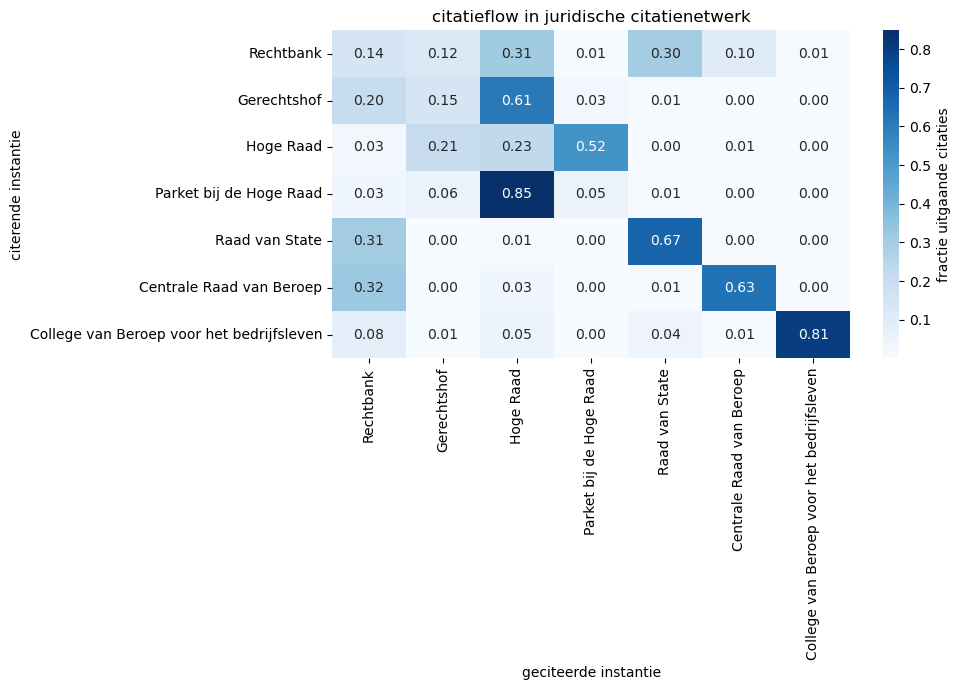

In [27]:
# plotten in heatmap



mat_row_norm = mat / mat.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(mat_row_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top7, yticklabels=top7, ax=ax,
            cbar_kws={'label': 'fractie uitgaande citaties'})
ax.set_xlabel('geciteerde instantie')
ax.set_ylabel('citerende instantie')
ax.set_title('citatieflow in juridische citatienetwerk')
plt.tight_layout()
plt.show()


### Conditionele citatiekansen tussen de top 7
\


$$P(\text{geciteerd}=j \mid \text{citerend}=i)$$

De kans dat een citatie uit een uitspraak van instantie i naar een uitspraak van instantie j gaat, en dat de geciteerde uitspraak tot een van de top 7 hoort.

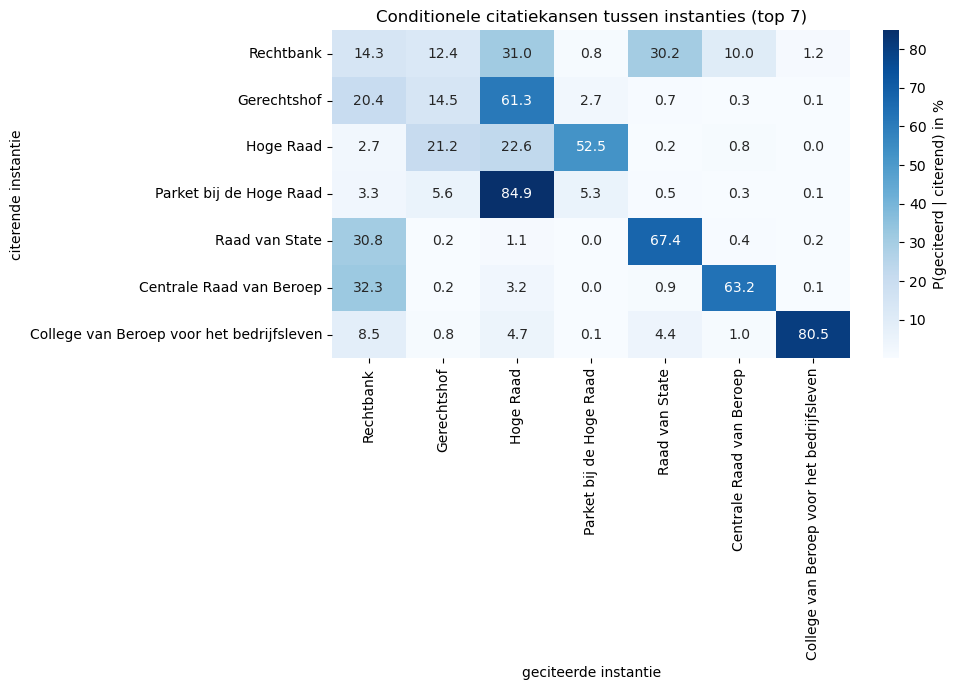

In [41]:
mat7_p = mat / mat.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(mat7_p * 100, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=top7, yticklabels=top7, ax=ax,
            cbar_kws={'label': 'P(geciteerd | citerend) in %'})
ax.set_xlabel('geciteerde instantie')
ax.set_ylabel('citerende instantie')
ax.set_title('Conditionele citatiekansen tussen instanties (top 7)')
plt.tight_layout()
plt.show()

## hoeveel blijft op de diagonaal

welk deel van de citaties binnen hetzelfde instantietype blijft. Een hoog deel op de diagonaal wijst op homofilie (rechtbanken citeren vooral rechtbanken), een laag deel op 

In [68]:
diag_total = np.trace(mat)
total = mat.sum()

print(f'Op de diagonaal (binnen eigen type):{diag_total:,.0f} ({diag_total/total*100:.1f}%)')
print(f'Buiten de diagonaal:{total-diag_total:,.0f} ({(1-diag_total/total)*100:.1f}%)')

print('Deel van de uitgaande citaties binnen het eigen type per instantie:')
for i, inst in enumerate(top7):
    rs = mat[i].sum()
    if rs > 0:
        print(f'  {inst:<45} {mat[i, i]/rs*100:5.1f}%')

Op de diagonaal (binnen eigen type):270,209 (23.8%)
Buiten de diagonaal:865,915 (76.2%)
Deel van de uitgaande citaties binnen het eigen type per instantie:
  Rechtbank                                      14.3%
  Gerechtshof                                    14.5%
  Hoge Raad                                      22.6%
  Parket bij de Hoge Raad                         5.3%
  Raad van State                                 67.4%
  Centrale Raad van Beroep                       63.2%
  College van Beroep voor het bedrijfsleven      80.5%


### De Onbekend-groep apart

"Onbekend" bevat uitspraken waarvan de ECLI-instantiecode niet in onze mapping zit ().  Hoe groot is deze groep , waar gaan citaties uit Onbekend heen, en is Onbekend voor elke citerende top-7-instantie

In [66]:
n_onb = inst_counts.get('Onbekend', 0)
print(f'Aantal Onbekend knopen: {n_onb:,} ({n_onb/G_jur.number_of_nodes()*100:.1f}% van alle knopen)')


j_onb = instanties.index('Onbekend')

print('\nUitgaande citaties uit Onbekend-uitspraken:')
row = mat[j_onb]
tot = row.sum()

order = np.argsort(-row)
for k in order:
    if row[k] > 0:
        print(f'  -> {instanties[k]:<45} {row[k]/tot*100:5.1f}%  (n={int(row[k]):,})')

print('\nFractie uitgaande citaties die NAAR Onbekend gaat, per citerende top-7-instantie:')
for inst in top7:
    i = instanties.index(inst)
    rs = mat_full[i].sum()

    print(f'  {inst:<45} {mat_full[i, j_onb]/rs*100:5.2f}%')


Aantal Onbekend knopen: 11,812 (1.8% van alle knopen)

Uitgaande citaties uit Onbekend-uitspraken:
  -> Onbekend                                       67.4%  (n=73,074)
  -> Centrale Raad van Beroep                       30.8%  (n=33,346)
  -> Gerechtshof                                     1.1%  (n=1,180)
  -> Overig (AGAMS)                                  0.4%  (n=392)
  -> College van Beroep voor het bedrijfsleven       0.2%  (n=224)
  -> Overig (AGROT)                                  0.2%  (n=171)
  -> Hoge Raad                                       0.0%  (n=25)

Fractie uitgaande citaties die NAAR Onbekend gaat, per citerende top-7-instantie:
  Rechtbank                                     19.52%
  Gerechtshof                                   12.91%
  Hoge Raad                                      7.84%
  Parket bij de Hoge Raad                        7.54%
  Raad van State                                10.41%
  Centrale Raad van Beroep                       6.74%
  College va

# newman assortativity op instantitype


In [70]:
nx.set_node_attributes(G_jur, node_inst, name='instantie')
r = nx.attribute_assortativity_coefficient(G_jur, 'instantie')



print(f'Newman assortativity op instantietype r = {r:.4f}')


Newman assortativity op instantietype r = 0.0910
Newman assortativity top 7 (zonder Onbekend):  r = nan


In [74]:
nodes_top7 = [n for n in G_jur if node_inst.get(n) in top7]

G_top7 = G_jur.subgraph(nodes_top7).copy()
nx.set_node_attributes(G_top7, node_inst, 'instantie')

r_top7 = nx.attribute_assortativity_coefficient(G_top7, 'instantie')
print(f'Newman assortativity op instantietype(top7): r = {r_top7:.4f}')


Newman assortativity op instantietype(top7): r = 0.1085


In [54]:
HIERARCHY = {
    'Rechtbank': 0,
    'Gerechtshof': 1,
    'Hoge Raad': 2,
    'Parket bij de Hoge Raad': 2,
    'Raad van State': 2,
    'Centrale Raad van Beroep': 2,
    'College van Beroep voor het bedrijfsleven': 2,
}


hoger, lager, same, other = 0, 0, 0, 0
for u, v in G_jur.edges():
    i, j = node_inst[u], node_inst[v]
    if i in HIERARCHY and j in HIERARCHY:
        if HIERARCHY[i] < HIERARCHY[j]:
            hoger += 1     # lager citeert hoger
        elif HIERARCHY[i] > HIERARCHY[j]:
            lager += 1   # hoger citeert lager
        else:
            same += 1   # zelfde niveau
    else:
        other += 1

total_count = hoger + lager + same

print(f'lager -> hoger: {hoger:>10,} ({hoger/total_count*100:.1f}%)')
print(f'hoger -> lager: {lager:>10,} ({lager/total_count*100:.1f}%)')
print(f'zelfde niveau:  {same:>10,} ({same/total_count*100:.1f}%)')
print(f'(onbekend instantietype): {other:,}')

lager -> hoger:    436,383 (38.4%)
hoger -> lager:    154,462 (13.6%)
zelfde niveau:     545,279 (48.0%)
(onbekend instantietype): 217,540


## Resultaten
**Afbakening tot zeven hoofdinstanties.** De ECLI-prefix levert voor het grootste deel van de uitspraken een eenduidig instantietype op. Voor de analyse worden de zeven hoofdcategorieën onderscheiden: Rechtbank (264.138 uitspraken), Gerechtshof (99.112), Hoge Raad (84.931), Parket bij de Hoge Raad (62.383), Raad van State (67.689), Centrale Raad van Beroep (61.825) en College van Beroep voor het bedrijfsleven (9.900). Samen vormen deze 649.978 knopen 96,4% van het netwerk. De overige 24.611 knopen vallen onder Onbekend (11.812),

**Conditionele citatiekansen P(geciteerd | citerend).** 
 
**Diagonaalfractie


**Onbekend-categorie.** De Onbekend-categorie bevat 11.812 knopen, 1,8% van het netwerk. Deze knopen zijn uitspraken waarvan de ECLI-instantiecode niet in de standaardmapping voorkomt. Dit zijn vooral oudere ECLI's en bijzondere instasties. Het aandeel van de uitgaande citaties dat per top-7-instantie naar Onbekend gaat is niet gelijk: het loopt uiteen van 6,74% (CRvB) tot 19,52% (Rechtbank), met een gemiddelde rond 11%

**Newman-assortativity.** Op het volledige netwerk geldt r = 0,091, bij beperking tot de zeven hoofdinstanties is er een coefficient van r = 0.1085. De hiërarchische structuur van het netwerk bevestigt dat citaties asymmetrisch verlopen: van de 1.136.124 citaties waarbij beide instanties behoren tot de hoofdcategorieën, loopt 48,0% binnen hetzelfde hiërarchische niveau, 38,4% van een lagere naar een hogere instantie en 13,6% van een hogere naar een lagere instantie. De verhouding lager → hoger tegen hoger → lager is ongeveer 2,8 : 1.



## Interpretatie 
De licht positieve assortativity (r = 0,091) gaat in tegen de verwachtiong van een sterk negatieve coëfficiënt. De conditionele kansen geven hiervoor een verklaring. Twee mechanismen verhogen de coëfficiënt, en samen compenseren zij ruim de "lager naar hoger"-stroom die anders naar negatieve assortativity zou neigen.



De zeer hoge PHR → HR stroom (202.605 citaties) bevestigt het beeld uit DV1 dat de cyclische kern van het netwerk grotendeels uit dit paar bestaat. 